In [89]:
import numpy as np
import scipy.signal as signal
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
# ============= ROM SETUP AND SIMULATION CASES =============
from pathlib import Path
import sys
project_root_str = str(Path(r'C:\Users\setemadi3\GaTech Dropbox\Seyednima Etemadi\Projects\Metamaterial beam'))
if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

import Modeling
import importlib
from Modeling.models import beam_properties
importlib.reload(beam_properties)


import Modeling.models.ROM1 as rom1_module

importlib.reload(rom1_module)
ROM = rom1_module.ROM
L_b = 55e-3

params_rom = beam_properties.PiezoBeamParams(
    config_name='series',
    rho_p=7600,
    rho_s=8500,
    s11=14.5e-12,
    E_s=100e9,
    d31=-19.5e-11*1.2,
    eps_r=1700/1.2,
    b=31.75e-3,
    hp=0.275e-3,
    hs=0.13e-3,
    n_patches=1,
    w_p=L_b,
    omega_p=110 * 2 * np.pi,
    omega_q=200 * 2 * np.pi,
)
params_rom.L_b = L_b
params_rom.xL = np.array([0.0])
params_rom.xR = np.array([L_b])
no_modes = 1
rom = ROM(params=params_rom, N=no_modes, modal_damping_ratios=np.array([0.004] * no_modes))
print('capacitance:', rom.p.Cp_scalar)
print('electromechanical coupling coefficient:', rom.Gamma.ravel()[0])
print('resonant frequency:', rom.omega[0] / (2 * np.pi))
print('modal forcing:', rom.sigma_r[0])

capacitance: 5.5669756609195396e-08
electromechanical coupling coefficient: -521.0381785544288
resonant frequency: 108.34115126845676
modal forcing: 0.07521994687670652


In [90]:
Fs = 100000
Ts = 1 / Fs
tf = 0.01

omega0 =  rom.omega[0] 
zeta = 0.005
theta = rom.Gamma.ravel()[0]*rom.p.theta_mech
Cp =  rom.p.Cp_scalar

def forcing_sine(t):
	return np.sin(2*np.pi*100*t)

Rc = 10000
L = 1 / (omega0**2 *  Cp)
R = 500e3

kp = Rc / R
ki = Rc / L
# ki = 1

num_cont = [kp, ki]
den_cont = [1, 0]
b_dig, a_dig, _ = signal.cont2discrete(
	(num_cont, den_cont),
	dt=Ts,
	method='bilinear'
)

b_dig = b_dig.flatten()

print("b_dig =", b_dig)
print("a_dig =", a_dig)


b_dig = [ 0.02128984 -0.01871016]
a_dig = [ 1. -1.]


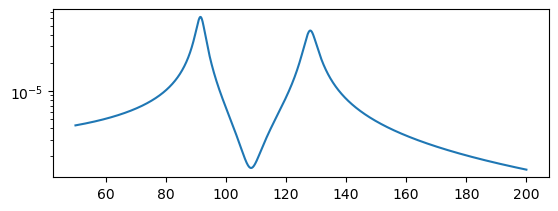

In [91]:
w = np.linspace(50, 200, 4000)*2*np.pi       



s = 1j*w
z = np.exp(1j*w*Ts)

Hd = (
	np.polyval(b_dig[::-1], z**-1)
	/
	np.polyval(a_dig[::-1], z**-1)
)

D = (
	s**2
	+
	2*zeta*omega0*s
	+
	omega0**2
	+
	(theta**2 * s)
	/
	(
		Cp*s
		+
		Hd/Rc
	)
)

H_eta = rom.sigma_r[0] / D

plt.figure()

plt.subplot(211)
plt.semilogy(w/2/np.pi, 20*np.abs(H_eta))

# plt.subplot(212)
# plt. semilogx(w, np.angle(H_eta, deg=True))

Text(0, 0.5, 'Magnitude [dB]')

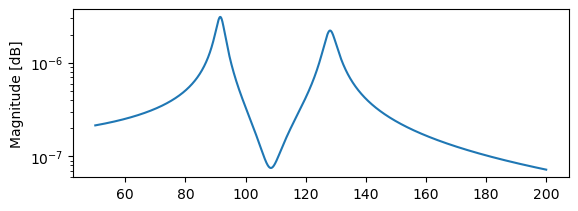

In [92]:

s = 1j*w

D_elec = (
	Cp*s**2
	+
	(kp/Rc)*s
	+
	ki/Rc
)

D = (
	s**2
	+
	2*zeta*omega0*s
	+
	omega0**2
	+
	(theta**2 * s**2)/D_elec
)

H_eta = rom.sigma_r[0] / D
plt.figure()

plt.subplot(211)
plt.semilogy(w/2/np.pi, np.abs(H_eta))
plt.ylabel("Magnitude [dB]")



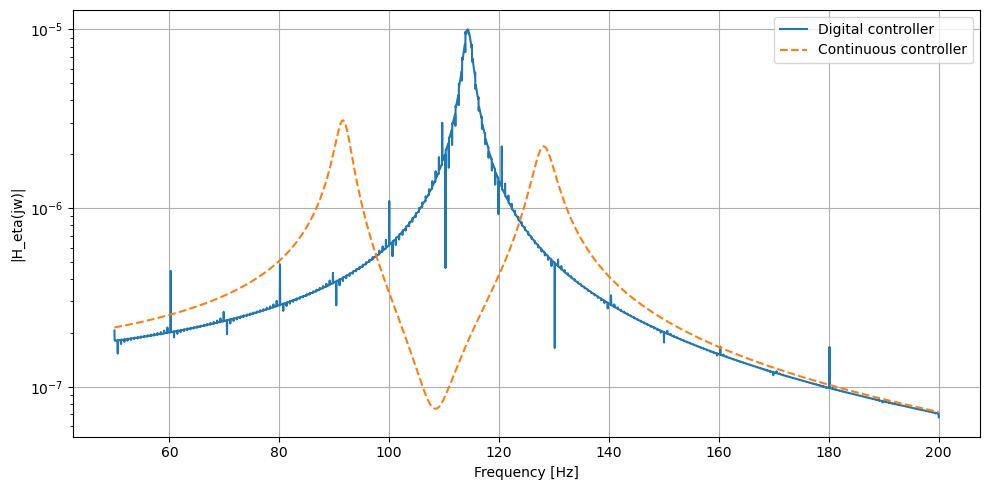

In [93]:
def compute_frequency_response(
    w,
    rom,
    omega0,
    zeta,
    theta,
    Cp,
    Rc,
    kp=None,
    ki=None,
    b_dig=None,
    a_dig=None,
    Ts=None,
    mode="digital",
):
    """Compute the mechanical frequency response H_eta(jw).

    Parameters
    ----------
    w : array_like
        Angular frequency grid [rad/s].
    rom : object
        Reduced-order model with sigma_r.
    omega0, zeta, theta, Cp, Rc : float
        Mechanical and electrical parameters.
    kp, ki : float, optional
        Continuous PI gains used when mode='continuous'.
    b_dig, a_dig : array_like, optional
        Discrete PI filter coefficients used when mode='digital'.
    Ts : float, optional
        Sample time used for the digital controller frequency mapping.
    mode : {'digital', 'continuous'}
        Selects the controller model.

    Returns
    -------
    H_eta : ndarray
        Complex frequency response evaluated at w.
    """

    w = np.asarray(w)
    s = 1j * w

    if mode == "digital":
        if b_dig is None or a_dig is None or Ts is None:
            raise ValueError("b_dig, a_dig, and Ts are required for mode='digital'.")
        z = np.exp(1j * w * Ts)
        Hd = np.polyval(np.asarray(b_dig).flatten()[::-1], z**-1) / np.polyval(
            np.asarray(a_dig).flatten()[::-1], z**-1
        )
        D = (
            s**2
            + 2 * zeta * omega0 * s
            + omega0**2
            + (theta**2 * s) / (Cp * s + Hd / Rc)
        )

    elif mode == "continuous":
        if kp is None or ki is None:
            raise ValueError("kp and ki are required for mode='continuous'.")
        D_elec = Cp * s**2 + (kp / Rc) * s + ki / Rc
        D = s**2 + 2 * zeta * omega0 * s + omega0**2 + (theta**2 * s**2) / D_elec

    else:
        raise ValueError("mode must be 'digital' or 'continuous'.")

    return rom.sigma_r[0] / D


# Example usage
w = np.linspace(50, 200, 4000) * 2 * np.pi
H_eta_digital = compute_frequency_response(
    w,
    rom,
    omega0,
    zeta,
    theta,
    Cp,
    Rc,
    b_dig=b_dig,
    a_dig=a_dig,
    Ts=Fs,
    mode="digital",
)

H_eta_continuous = compute_frequency_response(
    w,
    rom,
    omega0,
    zeta,
    theta,
    Cp,
    Rc,
    kp=kp,
    ki=ki,
    mode="continuous",
)

plt.figure(figsize=(10, 5))
plt.semilogy(w / (2 * np.pi), np.abs(H_eta_digital), label="Digital controller")
plt.semilogy(w / (2 * np.pi), np.abs(H_eta_continuous), '--', label="Continuous controller")
plt.xlabel("Frequency [Hz]")
plt.ylabel("|H_eta(jw)|")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [94]:



class RationalFilter:

	def __init__(self, b, a, Ts):

		self.b = np.asarray(b).flatten()
		self.a = np.asarray(a).flatten()

		self.Ts = Ts

		self.x_hist = np.zeros(len(self.b))
		self.y_hist = np.zeros(len(self.a)-1)

		self.y = 0.0
		self.t_next = 0.0

	def update(self, u):

		# input history
		self.x_hist[1:] = self.x_hist[:-1]
		self.x_hist[0] = u

		# difference equation
		y = np.dot(self.b, self.x_hist)

		if len(self.y_hist):
			y -= np.dot(self.a[1:], self.y_hist)

		y /= self.a[0]

		# output history
		if len(self.y_hist):
			self.y_hist[1:] = self.y_hist[:-1]
			self.y_hist[0] = y

		self.y = y
		self.t_next += self.Ts

	def output(self):

		return self.y


class HybridIVP:

	def __init__(self, rhs, filt):

		self.rhs = rhs
		self.filt = filt

	def solve(self, t0, tf, x0):

		t = t0
		x = np.asarray(x0, dtype=float)

		T = [t]
		X = [x.copy()]

		while t < tf:

			t_event = min(self.filt.t_next, tf)

			filt_out = self.filt.output()

			sol = solve_ivp(
				lambda t, x: self.rhs(t, x, filt_out),
				(t, t_event),
				x,
				max_step=Ts/2#1/(rom.omega[0] /2/np.pi)/20
			)

			T.extend(sol.t[1:])
			X.extend(sol.y.T[1:])

			x = sol.y[:, -1]
			t = sol.t[-1]

			# update digital filter with lambda_dot
			if t < tf:
				self.filt.update(x[2])

		return np.asarray(T), np.asarray(X)



def make_rhs_hybrid(forcing_func):

	def rhs_hybrid(t, x, filt_out):

		eta = x[0]
		eta_dot = x[1]
		lam_dot = x[2]

		# mechanical equation
		eta_ddot = (
			forcing_func(t) * rom.sigma_r[0]
			- 2*zeta*omega0*eta_dot
			- omega0**2 * eta
			+ theta*lam_dot
		)

		# electrical equation
		lam_ddot = (
			- filt_out/Rc
			- theta*eta_dot
		) / Cp

		return np.array([
			eta_dot,
			eta_ddot,
			lam_ddot
		])

	return rhs_hybrid


def make_rhs_continuous(forcing_func):

	def rhs_continuous(t, x):

		eta = x[0]
		eta_dot = x[1]

		lam = x[2]
		lam_dot = x[3]

		# continuous filter output
		y = kp*lam_dot + ki*lam

		# mechanical equation
		eta_ddot = (
			forcing_func(t) * rom.sigma_r[0]
			- 2*zeta*omega0*eta_dot
			- omega0**2 * eta
			+ theta*lam_dot
		)

		# electrical equation
		lam_ddot = (
			- y/Rc
			- theta*eta_dot
		) / Cp

		return np.array([
			eta_dot,
			eta_ddot,
			lam_dot,
			lam_ddot
		])

	return rhs_continuous

forcing = forcing_sine
rhs_hybrid = make_rhs_hybrid(forcing)
rhs_continuous = make_rhs_continuous(forcing)


# ============================================================
# CONTINUOUS REFERENCE SYSTEM
#
# States:
#
# x[0] = eta
# x[1] = eta_dot
# x[2] = lambda
# x[3] = lambda_dot
#
# Continuous PI:
#
# y = kp*lambda_dot + ki*lambda
# ============================================================

# ============================================================
# Run hybrid simulation
# ============================================================

filt = RationalFilter(
	b_dig,
	a_dig,
	Ts
)

hybrid_solver = HybridIVP(
	rhs_hybrid,
	filt
)

T_h, X_h = hybrid_solver.solve(
	0.0,
	tf,
	[
		0.0,   # eta
		0.0,   # eta_dot
		0.0    # lambda_dot
	]
)


# ============================================================
# Run continuous reference simulation
# ============================================================

sol_c = solve_ivp(
	rhs_continuous,
	(0.0, tf),
	[
		0.0,   # eta
		0.0,   # eta_dot
		0.0,   # lambda
		0.0    # lambda_dot
	],
	max_step=Ts
)

T_c = sol_c.t
X_c = sol_c.y.T


# ============================================================
# Plot eta comparison
# ============================================================


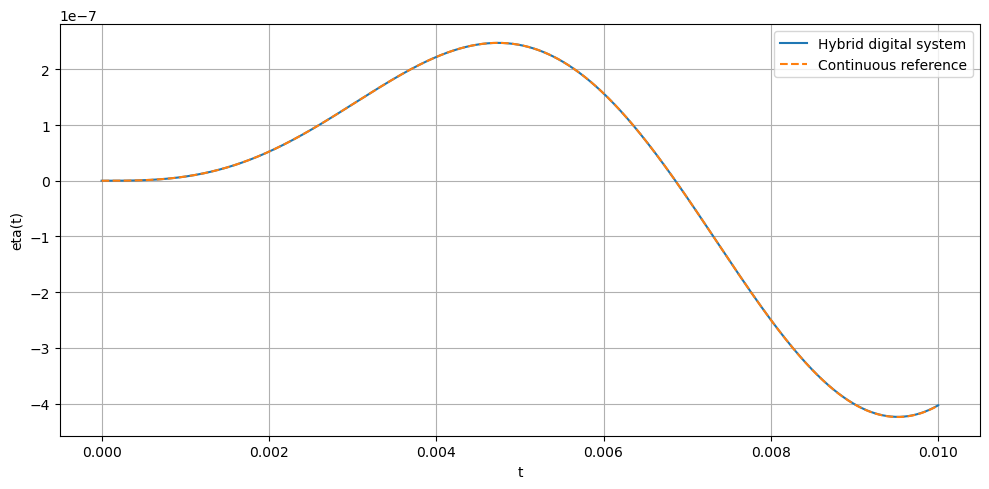

In [95]:

plt.figure(figsize=(10, 5))

plt.plot(
	T_h,
	X_h[:, 0],
	label="Hybrid digital system"
)

plt.plot(
	T_c,
	X_c[:, 0],
	'--',
	label="Continuous reference"
)
# plt.ylim([-0.05, 0.05])
# plt.xlim([0, 1e-3])
plt.xlabel("t")
plt.ylabel("eta(t)")

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [96]:
# ============================================================
# Arbitrary forcing, spectral analysis, and FRF calculation
# ============================================================

from scipy.signal import chirp

# Example forcing: chirp. Replace this function with any forcing_func(t).
f_start = 70
f_end = 150
amp_chirp = 0.03
tf = 1
Ts = 1/(rom.omega[0]/2/np.pi)/50

def forcing_chirp(t):
    return amp_chirp * chirp(t, f0=f_start, f1=f_end, t1=tf, method='linear')

rhs_forcing = make_rhs_continuous(forcing_chirp)
T_forcing = np.arange(0.0, tf, Ts)
sol_forcing = solve_ivp(
    rhs_forcing,
    (0.0, tf),
    [0.0, 0.0, 0.0, 0.0],
    t_eval=T_forcing,
    max_step=Ts
)


# FFT-based FRF estimate using input force and output displacement
u_uniform = forcing_chirp(T_forcing)
eta =  sol_forcing.y.T[:, 0]
t = sol_forcing.t


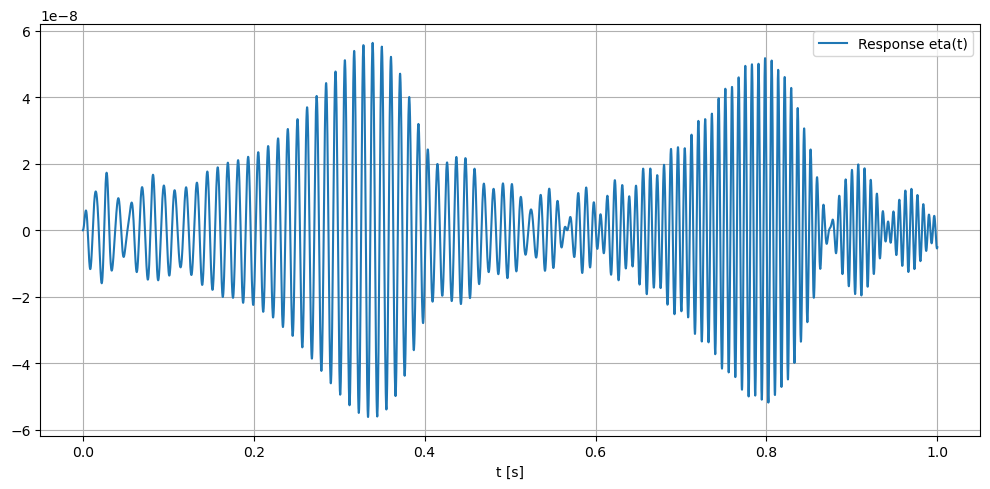

In [97]:

plt.figure(figsize=(10, 5))
# plt.plot(t, forcing_chirp(t), label='chirp input')
plt.plot( t, eta, label='Response eta(t)')
# plt.xlim([1e-1,1e-1])
# plt.ylim([-1e-7,1e-7])
plt.xlabel('t [s]')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# fig, ax = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
# plt.plot(f_fft, 20*np.log10(np.maximum(H_mag, 1e-20)))

# plt.show()
